### Importing Packages

In [81]:
## Importing Packages 
import warnings
warnings.filterwarnings("ignore")

from typing import Dict
import os
import ssl
import openpyxl
import sys
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import textwrap
import seaborn as sns
import yfinance as yf

import random
from scipy import stats
from scipy.stats import skew, kurtosis, ttest_ind

In [89]:
## Importing Complexity Theory Functions and Indicators
sys.path.insert(0, r"C:\Users\Admin\Documents\GitHub\Complexity-Theory-Masters-Thesis\Complexity_Theory_Indicators")

from Complexity_Theory_Functions_Master import ar1_phi, decay_rate_from_phi, decay_rate_from_N_ratio, sarle_bimodality, rolling_complexity_indicators, tail_signals, set_theme_like_example, plot_all_indicators, ews_score_from_valid, plot_spread_with_ews_overlay

### Setting Plotting Theme

In [85]:
## Setting Plotting Theme
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True
%matplotlib inline

sns.set_theme(
        style="darkgrid",
        context="notebook",
        font_scale=1.1,
        rc={
            "axes.facecolor": "#EAEAF2",
            "figure.facecolor": "white",
            "grid.color": "white",
            "grid.linewidth": 1.0,
            "axes.edgecolor": "#EAEAF2",
            "axes.labelweight": "bold",
            "axes.titleweight": "bold",
        },
    )

### Data

In [11]:
file_path = r'C:\Users\Admin\Documents\GitHub\Complexity-Theory-Masters-Thesis\Data'
os.chdir(file_path)

In [12]:
## Reading-in the data
df_spain_yields = pd.read_excel("Spread_Data.xlsx", sheet_name="Spain_Benchmark_Yields").copy()
df_germany_yields = pd.read_excel("Spread_Data.xlsx", sheet_name="Germany_Benchmark_Yields").copy()
df_us_indices = pd.read_excel("US_spreads_GFC.xlsx", sheet_name="GFC_Spreads").copy()

df_spain_yields["Date"] = pd.to_datetime(df_spain_yields["Date"])
df_germany_yields["Date"] = pd.to_datetime(df_germany_yields["Date"])
df_us_indices["Date"] = pd.to_datetime(df_us_indices["Date"])

df_spain_yields = df_spain_yields.set_index("Date").sort_index()
df_germany_yields = df_germany_yields.set_index("Date").sort_index()
df_us_indices = df_us_indices.set_index("Date").sort_index()

df_spain_yields = df_spain_yields.dropna()
df_germany_yields = df_germany_yields.dropna()
df_us_indices = df_us_indices.dropna()

In [13]:
df_spain_yields

,SPAIN GVT BMK BID YLD 5Y,SPAIN GVT BMK BID YLD 10Y,SPAIN GVT BMK BID YLD 30Y
Date,,,
1999-12-31,5.129,5.572,6.113
2000-01-03,5.219,5.690,6.186
2000-01-04,5.246,5.763,6.204
2000-01-05,5.238,5.744,6.205
2000-01-06,5.256,5.781,6.274
...,...,...,...
2026-03-05,2.757,3.312,4.030
2026-03-06,2.819,3.363,4.052
2026-03-09,2.819,3.355,4.052


#### Construction of the Spain–Germany Sovereign Spread

*The baseline spread series is constructed from daily 5Y, 10Y and 30Y rolling benchmark government bond yields for Spain and Germany. These benchmark yields provide liquid market reference rates for each maturity, though they do not correspond to a single fixed security over time.*

For our thesis, we define the sovereign spread as:

$$
\text{Spread}_t = y^{\text{Spain}}_t - y^{\text{Germany}}_t
$$

where:

- $y^{\text{Spain}}_t$ is the Spanish government bond yield at time $t$
- $y^{\text{Germany}}_t$ is the German government bond yield at time $t$

Thus, the spread is computed by **subtracting the German yield from the Spanish yield**.

##### Interpretation

This definition is appropriate because Germany serves as the core benchmark sovereign issuer in the euro area, while Spain is treated as the relatively riskier issuer. Therefore:

- a **higher spread** indicates greater relative stress or risk in Spanish sovereign bonds,
- a **declining spread** indicates relative stabilization,
- and a **widening spread** is naturally interpretable as deterioration in Spain relative to Germany.

For this reason, the spread should be constructed as:

- **5Y spread** = Spain 5Y yield − Germany 5Y yield
- **10Y spread** = Spain 10Y yield − Germany 10Y yield
- **30Y spread** = Spain 30Y yield − Germany 30Y yield

Although, in this notebook we will primarily focus on the **5Y spread** 

In [14]:
## Build all Spain-Germany spreads dataframe
spreads = (
    pd.DataFrame({
        "5Y":  df_spain_yields["SPAIN GVT BMK BID YLD 5Y"]  - df_germany_yields["GERMANY GVT BMK BID YLD 5Y"],
        "10Y": df_spain_yields["SPAIN GVT BMK BID YLD 10Y"] - df_germany_yields["GERMANY GVT BMK BID YLD 10Y"],
        "30Y": df_spain_yields["SPAIN GVT BMK BID YLD 30Y"] - df_germany_yields["GERMANY GVT BMK BID YLD 30Y"],
    })
    .rename(columns={"5Y": "ES-DE 5Y", "10Y": "ES-DE 10Y", "30Y": "ES-DE 30Y"})
)
es_de_spread_5y = df_spain_yields['SPAIN GVT BMK BID YLD 5Y'] - df_germany_yields['GERMANY GVT BMK BID YLD 5Y']
es_de_spread_5y_df = es_de_spread_5y.to_frame(name='es_de_5y_spread')
es_de_spread_10y = df_spain_yields['SPAIN GVT BMK BID YLD 10Y'] - df_germany_yields['GERMANY GVT BMK BID YLD 10Y']
es_de_spread_10y_df = es_de_spread_10y.to_frame(name='es_de_10y_spread')
es_de_spread_30y = df_spain_yields['SPAIN GVT BMK BID YLD 30Y'] - df_germany_yields['GERMANY GVT BMK BID YLD 30Y']
es_de_spread_30y_df = es_de_spread_30y.to_frame(name='es_de_30y_spread')

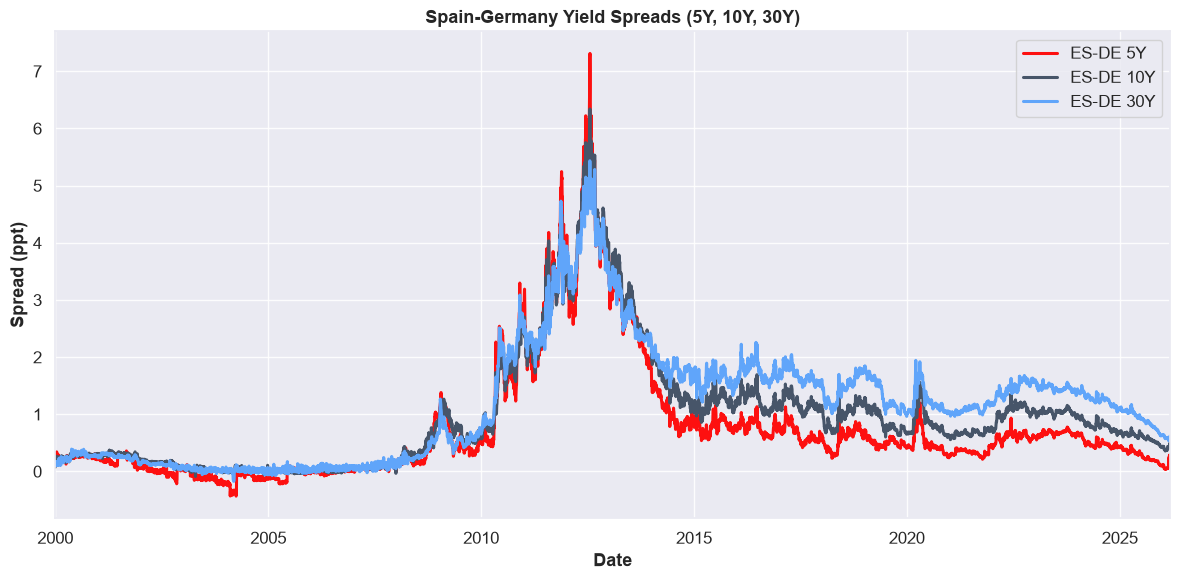

In [15]:
## Plotting all spreads
colors = ["#FD1010", "#475569", "#60A5FA"]  # 5Y, 10Y, 30Y
ax = spreads.plot(figsize=(12, 6), color=colors, linewidth=2.2, title="Spain-Germany Yield Spreads (5Y, 10Y, 30Y)")
ax.set_ylabel("Spread (ppt)")
ax.set_xlabel("Date")
ax.grid(True, which="major", color="white", alpha=0.9, linewidth=1.0)
plt.tight_layout()
plt.show()

### Looking at Major Sovereign Debt Crisis Events

In [ ]:
def annotate_events(ax, returns, events, position='top'):
    """
    Annotates major historical events on a matplotlib axis.
    
    Parameters:
        ax (matplotlib.axes.Axes): The axis to annotate on.
        returns (pd.Series): The time-indexed return series used to set x-axis limits.
        events: the events with their corresponding colour codes, that we want to plot
        position: either 'top' or 'bottom', for the annotated text
    
    | Event Type             | Color       |
    | ---------------------- | ----------- |
    | Institutional adoption | `darkgreen` |
    | Regulatory / ETF       | `blue`      |
    | Crashes / hacks        | `red`       |
    | Market milestones      | `orange`    |
    | Halvings               | `purple`    |
    """
    
    for date, label, color in events:
            date = pd.to_datetime(date)
            if returns.index.min() <= date <= returns.index.max():
                ax.axvline(date, color=color, linestyle='--', linewidth=1, alpha=0.7)
    
                # Choose Y position and vertical alignment
                if position == 'top':
                    y = ax.get_ylim()[1]
                    va = 'top'
                elif position == 'bottom':
                    y = ax.get_ylim()[0]
                    va = 'bottom'
                else:
                    y = ax.get_ylim()[1]
                    va = 'top'  # default fallback
    
                ax.text(date, y, label, rotation=90, va=va, ha='right', fontsize=10, color=color)

In [17]:
# --- Sovereign Debt Crisis Significant Dates ---
sov_event_legend = [
    Patch(color='red', label='Fiscal Stress / Disclosure'),
    Patch(color='blue', label='ECB Market Intervention'),
    Patch(color='darkgreen', label='ECB Liquidity Operations (LTRO)'),
    Patch(color='orange', label='Program / Policy Milestone'),
    Patch(color='purple', label='Acute Crisis Window Cutoff'),
]

sov_events = [
    ("2009-10-16", "Greek Fiscal Disclosure", "red"),
    ("2009-11-05", "Revised Greek Deficit Announcement", "red"),

    ("2010-05-10", "Securities Markets Programme (SMP) Launched", "blue"),
    ("2011-08-07", "SMP Expansion to Italy/Spain", "blue"),

    ("2011-12-08", "3Y LTRO Announcement", "darkgreen"),
    ("2011-12-21", "1st 3Y LTRO Allotment", "darkgreen"),
    ("2012-02-29", "2nd 3Y LTRO Allotment", "darkgreen"),

    ("2012-06-27", "Spain Requests Banking-Sector Assistance", "orange"),
    ("2012-07-26", "Draghi 'Whatever It Takes' Speech", "orange"),
    ("2012-09-06", "OMT Technical Features Announced", "blue"),

    ("2013-07-31", "Cutoff: End of Acute Sovereign-Crisis Window", "purple"),
]

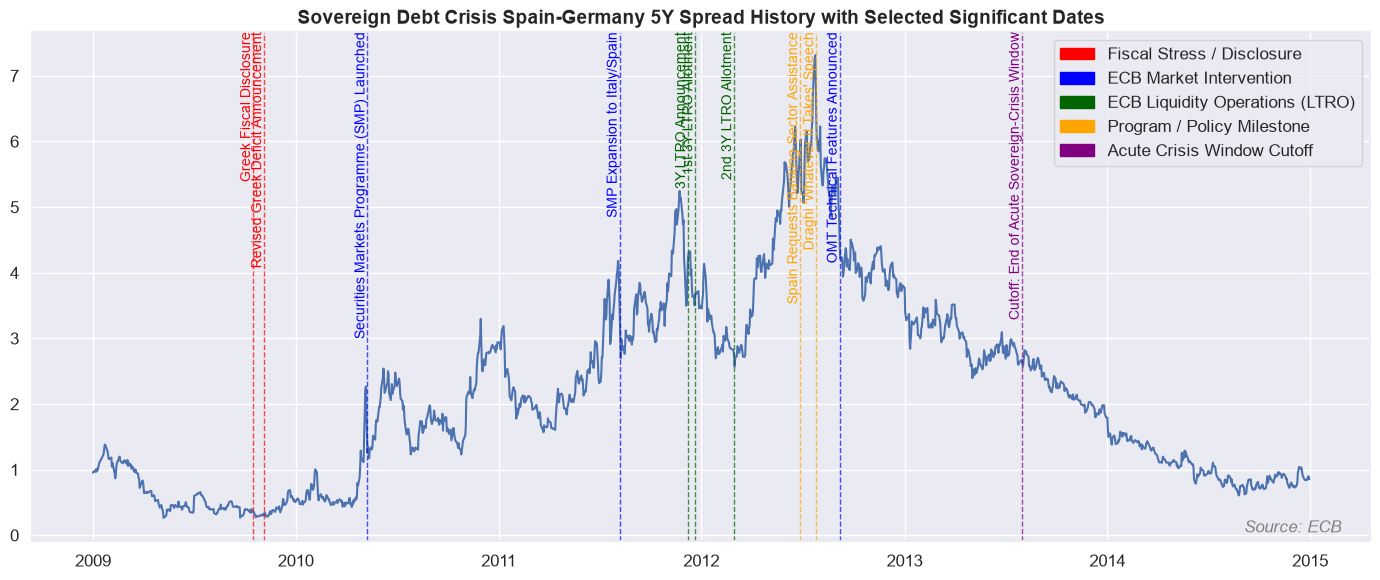

In [18]:
#==================
df_filtered = es_de_spread_5y_df.copy()
df_filtered = df_filtered['2009':'2014'].copy()  # Filter data / Zoom
column_label = 'es_de_5y_spread'
year = '5Y'
source = 'ECB'
#==================

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_filtered.index, df_filtered[column_label])
ax.set_title(f'Sovereign Debt Crisis Spain-Germany {year} Spread History with Selected Significant Dates', fontsize=14, fontweight='bold')
annotate_events(ax, df_filtered[column_label], sov_events, position='top')
ax.legend(handles=sov_event_legend, loc='upper right')
fig.text(0.965, 0.09, f'Source: {source}', ha='right', va='bottom', fontsize=12, style='italic', color='gray')
plt.tight_layout()
plt.show()

### Looking at Complexity Theory indicators

#### Expected pre-regime-shift pattern of each complexity indicator

- **Slowdown / decay rate (τ)**
  - Should **decline** as the system approaches the tipping point.
  - Interpretation: recovery back to the old equilibrium becomes slower and the system loses resilience.
  - In trend terms, the expected pre-transition pattern is a **downward trend**.
  - In threshold terms, the warning signal is when the indicator moves into the **lower tail** of its historical distribution.

- **Autocorrelation (ρ)**
  - Should **increase** before a regime shift.
  - Interpretation: the system develops more “memory”; the current state becomes increasingly similar to its past state.
  - In trend terms, the expected pre-transition pattern is an **upward trend**.
  - In threshold terms, the warning signal is when the indicator moves into the **upper tail** of its historical distribution.

- **Variance (σ²)**
  - Should **increase** before a regime shift.
  - Interpretation: shocks decay less, so their cumulative impact grows and the state variable becomes more volatile.
  - In trend terms, the expected pre-transition pattern is an **upward trend**.
  - In threshold terms, the warning signal is when the indicator moves into the **upper tail** of its historical distribution.

- **Skewness (γ)**
  - Should **increase** before a regime shift.
  - Interpretation: fluctuations become more asymmetric because the system spends more time near the unstable equilibrium / new state.
  - In trend terms, the expected pre-transition pattern is an **upward trend**.
  - In threshold terms, the warning signal is when the indicator moves into the **upper tail** of its historical distribution.

- **Flickering (β)**
  - Should **increase** before a regime shift.
  - Interpretation: the system starts oscillating between the old and the new state, so the distribution increasingly becomes a mixture of regimes.
  - In trend terms, the expected pre-transition pattern is an **upward trend**.
  - In threshold terms, the warning signal is when the indicator moves into the **upper tail** of its historical distribution.

**So in conclusion, before a regime shift, complexity theory predicts:**
- **τ ↓**
- **ρ ↑**
- **σ² ↑**
- **γ ↑**
- **β ↑**

#### Analysing Spanish Banking Sector Assistance

In [19]:
## We will use the date of Spain's request for banking-sector assistance as the crisis date for our current analysis
crisis_date = "2012-06-27"

## For our end data we will use the day before the crisis date, and for our start date we will use January 1, 2000
## This way the actual crisis day will be excluded from the analysis
s_date = "2000-01-01"
e_date = "2012-06-26"

## We will use the Spain-Germany 5Y Spread for our analysis, as it is the most sensitive to the acute sovereign debt crisis
es_de_spread_5y_df.head()

,es_de_5y_spread
Date,
1999-12-31,0.329
2000-01-03,0.324
2000-01-04,0.320
2000-01-05,0.320
2000-01-06,0.297


In [21]:
## Let's take a look at the dynamics around the selected crisis date. We will focus on the 5-year spread and its complexity indicators, as this is a common maturity for sovereign bond analysis and should provide insights into the market conditions during the crisis.
df_sov_stress_5y = es_de_spread_5y_df.loc[s_date:e_date].copy()
rolling_complexity_inds_5y = rolling_complexity_indicators(df=df_sov_stress_5y, value_col="es_de_5y_spread", date_col="Date", window=100, min_periods=100, signed_decay=False).copy()
rolling_complexity_inds_5y.tail()

,Autocorrelation (ρ),Slowdown Indicator (τ),Flickering (β),Variance (σ2),Skewness (γ)
observation_date,,,,,
2012-06-20,0.998175,0.001827,0.616165,1.072042,0.435803
2012-06-21,0.993931,0.006088,0.615060,1.081717,0.397445
2012-06-22,0.990767,0.009275,0.611704,1.082666,0.358464
2012-06-25,0.995004,0.005008,0.611170,1.095649,0.323308
2012-06-26,0.997491,0.002512,0.610155,1.113481,0.293562


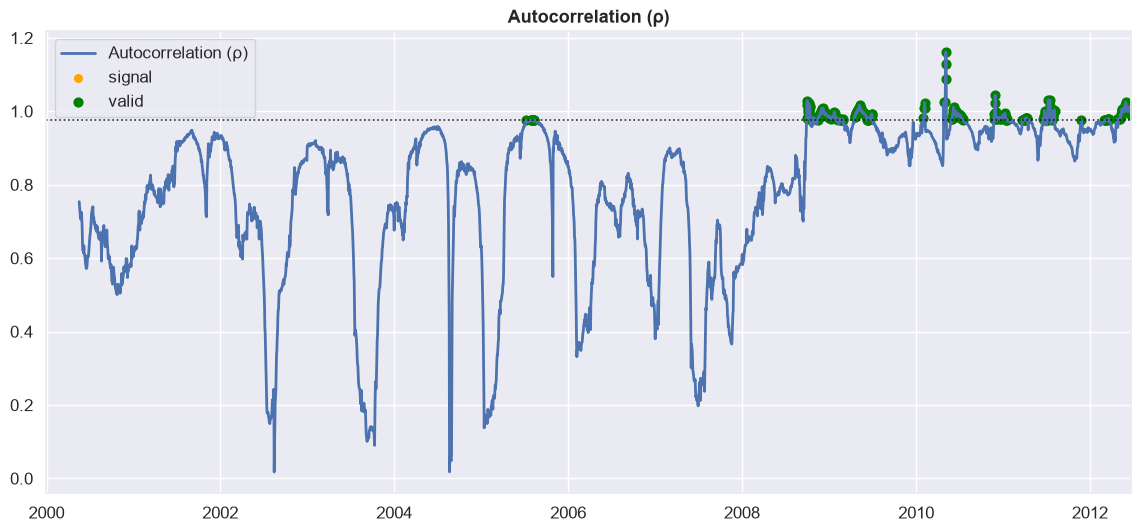

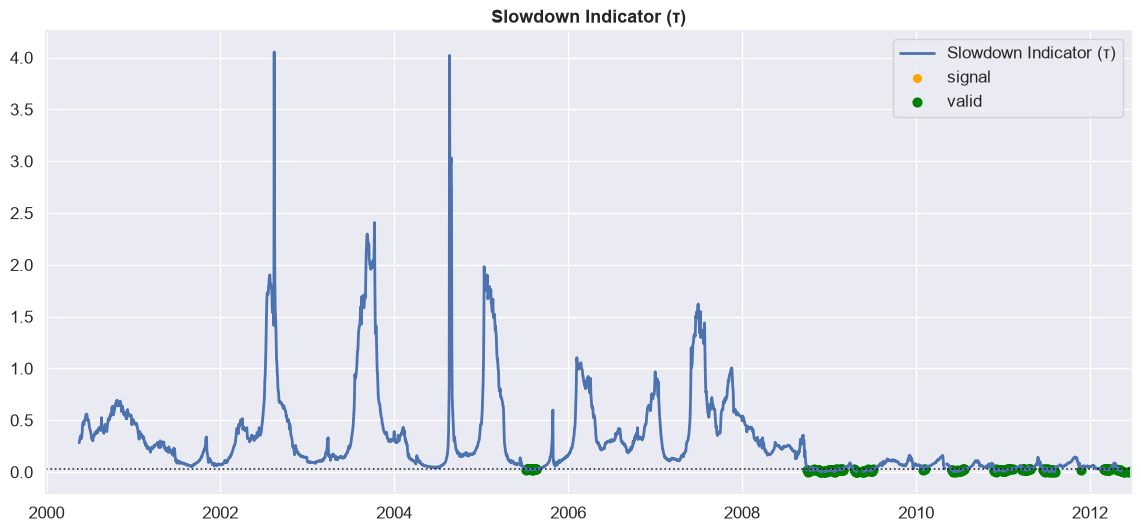

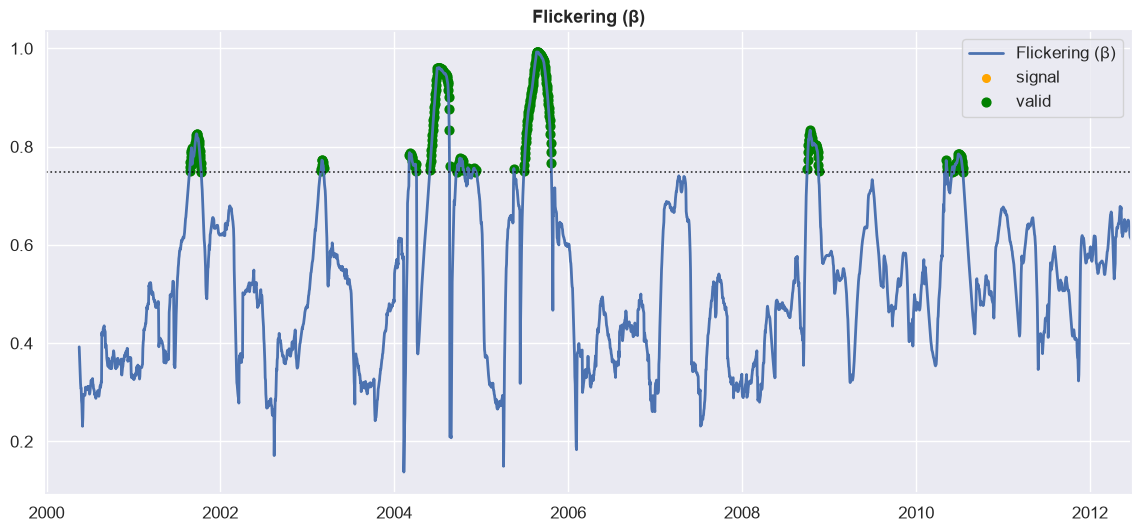

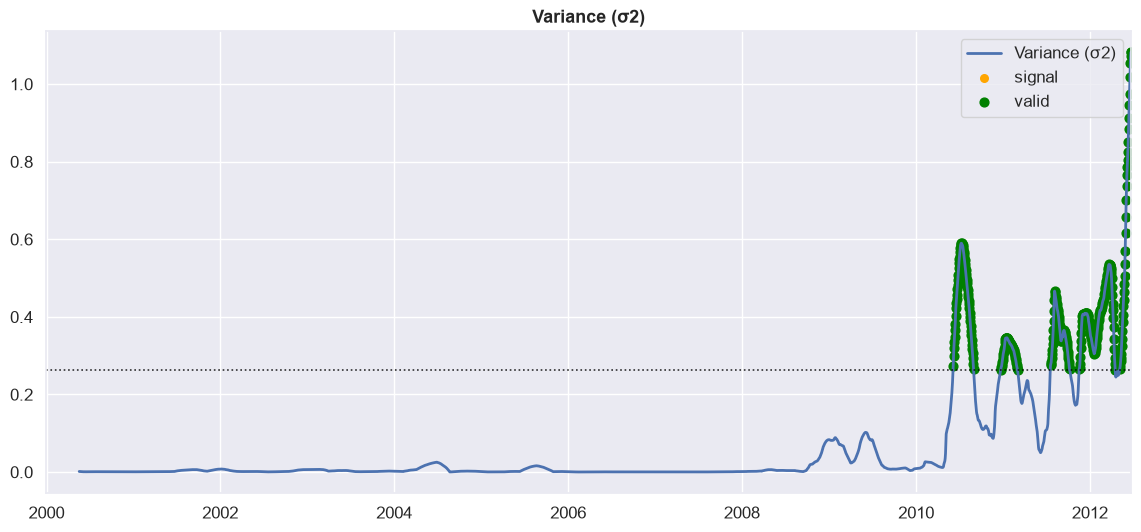

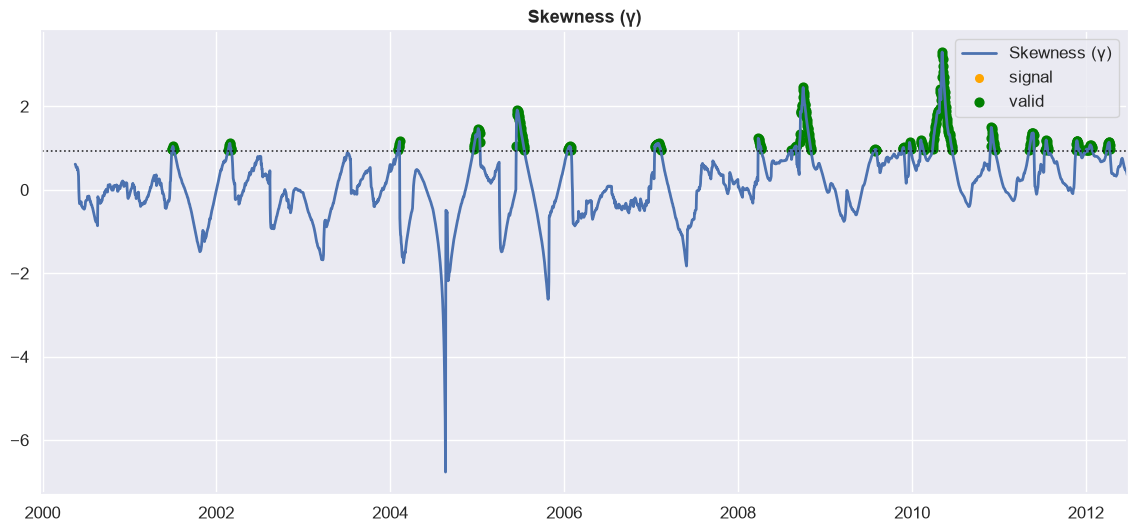

In [ ]:
## Plotting each rolling complexity indicator preceding the Spanish Banoking Assistance (2012-06-27)

crisis_dates = [crisis_date]
cutoff_for_extreme_tail = 0.1 # we will look at the lowest/highest 10% of the distribution of each complexity indicator as potential extreme-tail signals (following van den end (2019))

# A signal is “valid” if it is an extreme-tail signal and it happened within the last lookback (e.g. 100 days before the crisis) observations before the selected crisis date
thresholds, signals, valid, summary = tail_signals(rolling_complexity_inds_5y, crisis_dates, tail=cutoff_for_extreme_tail, lookback=100, check_all_signals=True)
ews = ews_score_from_valid(valid) # calculating EWS score based on valid signals

plot_all_indicators(rolling_complexity_inds_5y, crisis_dates[0], thresholds=thresholds, signals=signals, valid=valid, start_date=s_date, end_date=e_date)

#### Analysing Early Warning Signals (EWS) for Sovereign Debt Crisis Episodes

**We group the major sovereign debt crisis events into episodes for cleaner analysis based on the literature and ECB/IMF reports:**

| Episode                      | Dates included                     | Main anchor date                 | Reason                                         |
| ---------------------------- | ---------------------------------- | -------------------------------- | ---------------------------------------------- |
| Greek fiscal shock           | 2009-10-16, 2009-11-05             | **2009-10-16** or **2009-11-05** | Same disclosure/repricing episode              |
| First euro-area intervention | 2010-05-10                         | **2010-05-10**                   | Standalone SMP launch                          |
| Spain/Italy contagion        | 2011-08-07                         | **2011-08-07**                   | Standalone SMP expansion to Spain/Italy        |
| LTRO liquidity episode       | 2011-12-08, 2011-12-21, 2012-02-29 | **2011-12-08**                   | Same 3Y LTRO policy package                    |
| Spanish/OMT crisis episode   | 2012-06-27, 2012-07-26, 2012-09-06 | **2012-06-27** or **2012-07-26** | Same summer-2012 fragmentation episode         |
| Crisis-window cutoff         | 2013-07-31                         | Exclude from hit-rate            | Not a stress event, only an operational cutoff |


In [38]:
episode_events = [
    ("2009-10-16", "Greek fiscal disclosure episode"),
    ("2010-05-10", "First ECB sovereign-market intervention episode"),
    ("2011-08-07", "Spain/Italy contagion and SMP expansion episode"),
    ("2011-12-08", "3Y LTRO liquidity episode"),
    ("2012-06-27", "Spanish banking-sector assistance / summer 2012 stress episode"),
]
event_dates = [d for d, _ in episode_events]
event_dates

['2009-10-16', '2010-05-10', '2011-08-07', '2011-12-08', '2012-06-27']

* In order to move from individual complexity indicators to one composite early-warning score we first use a 100-trading-day rolling window, so each daily value reflects the recent behaviour of the Spain-Germany 5-year spread.
* Within each window, we compute our five indicators: critical slowing down, autocorrelation, variance, skewness, and flickering.
* Each indicator is then compared with its historical distribution.
* A signal is triggered when the indicator enters its relevant 10% tail: lower tail for critical slowdown, upper tail for the other indicators.
* The EWS score is simply the number of active signals on each day, so it ranges from 0 to 5.
* We treat a score of 3 or more as a warning, because it means a majority of indicators are simultaneously pointing to abnormal spread dynamics and evidence of market fragility.
* (One important caveat is that the thresholds are retrospective, so this should be interpreted as an ex-post diagnostic framework, not a real-time trading signal.)


In [ ]:
## Function for aggregating Early Warning Signals (EWS) around specified event dates, and generating a diagnostic table for the pre-event window.

def ews_event_window_table(
    df: pd.DataFrame,
    event_dates,
    ews_col: str = "EWS",
    signal_threshold: int = 3,
    pre_window: int = 100,
    horizons=(5, 10, 25, 50, 100)
):
    """
    Simple event-window diagnostic for an aggregate EWS score.

    For each event date, the function checks whether the EWS score gave
    a warning in the pre-event window.

    A warning is defined as:
        EWS_score >= signal_threshold
    """

    df = df.sort_index().copy()
    event_dates = pd.to_datetime(event_dates)

    rows = []

    for event_date in event_dates:
        pos = df.index.searchsorted(event_date)

        if pos == 0:
            continue

        start_pos = max(0, pos - pre_window)
        pre = df.iloc[start_pos:pos].copy()

        if pre.empty:
            continue

        signal = pre[ews_col] >= signal_threshold
        signal_dates = pre.index[signal]

        if len(signal_dates) > 0:
            first_signal_date = signal_dates[0]
            last_signal_date = signal_dates[-1]
            first_lead_days = pos - df.index.get_loc(first_signal_date)
            last_lead_days = pos - df.index.get_loc(last_signal_date)
            any_signal = 1
        else:
            first_signal_date = pd.NaT
            last_signal_date = pd.NaT
            first_lead_days = np.nan
            last_lead_days = np.nan
            any_signal = 0

        row = {
            "event_date": event_date,
            "any_signal_pre_100d": any_signal,
            "first_signal_date": first_signal_date,
            "first_signal_lead_days": first_lead_days,
            "last_signal_date": last_signal_date,
            "last_signal_lead_days": last_lead_days,
            "signal_days_pre_100d": int(signal.sum()),
            "signal_share_pre_100d": signal.mean(),
            "max_EWS_pre_100d": pre[ews_col].max(),
            "mean_EWS_pre_100d": pre[ews_col].mean(),
            "last_EWS_before_event": pre[ews_col].iloc[-1],
        }

        # EWS level exactly h trading days before event
        for h in horizons:
            if pos - h >= 0:
                row[f"EWS_{h}d_before"] = df[ews_col].iloc[pos - h]
            else:
                row[f"EWS_{h}d_before"] = np.nan

        # Any signal within shorter windows
        for h in horizons:
            if pos - h >= 0:
                short_pre = df.iloc[pos - h:pos]
                row[f"any_signal_pre_{h}d"] = int((short_pre[ews_col] >= signal_threshold).any())
                row[f"signal_days_pre_{h}d"] = int((short_pre[ews_col] >= signal_threshold).sum())
                row[f"max_EWS_pre_{h}d"] = short_pre[ews_col].max()
            else:
                row[f"any_signal_pre_{h}d"] = np.nan
                row[f"signal_days_pre_{h}d"] = np.nan
                row[f"max_EWS_pre_{h}d"] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [41]:
## We will now analyse the behaviour of the indicators around the selected crisis date, and generate a diagnostic table for the pre-event window

cutoff_for_extreme_tail = 0.1 # we will look at the lowest/highest 10% of the distribution of each complexity indicator as potential extreme-tail signals
ews_table = pd.DataFrame() # initialize empty table to store results for all events

for j,k in enumerate(event_dates):
    # Set date range for analysis
    e_date = pd.to_datetime(k) - pd.Timedelta(days=5)
    print(f"Selected date range for analysis: {s_date} to {e_date.strftime('%Y-%m-%d')}")

    # calculating rolling complexity indicators for the selected event date
    df_sov_stress_5y = es_de_spread_5y_df.loc[s_date:e_date.strftime('%Y-%m-%d')].copy()
    rolling_complexity_inds_5y = rolling_complexity_indicators(df=df_sov_stress_5y, value_col="es_de_5y_spread", date_col="observation_date", window=100, min_periods=100, signed_decay=False).copy()

    # calculating complexity indicator signals and ews scores
    crisis_dates = [k]
    thresholds, signals, valid, summary = tail_signals(rolling_complexity_inds_5y, crisis_dates, tail=cutoff_for_extreme_tail, lookback=100, check_all_signals=True)
    ews = ews_score_from_valid(valid) # calculating EWS score based on valid signals

    # creating event window table for the selected event date
    ews_event_table = ews_event_window_table(
        df=ews.to_frame(name="EWS"), # ews
        event_dates=[k],
        ews_col="EWS", # matters if ews has multiple columns
        signal_threshold=3,
        pre_window=100,
        horizons=(5, 10, 25, 50, 100)
    )
    
    # optional: tag which loop/event it came from
    ews_event_table["event_idx"] = j
    ews_event_table["event_date_input"] = pd.to_datetime(k)

    ews_table = pd.concat([ews_table, ews_event_table], ignore_index=True)

Selected date range for analysis: 1999-12-31 to 2009-10-11
Selected date range for analysis: 1999-12-31 to 2010-05-05
Selected date range for analysis: 1999-12-31 to 2011-08-02
Selected date range for analysis: 1999-12-31 to 2011-12-03
Selected date range for analysis: 1999-12-31 to 2012-06-22


In [42]:
ews_table

,event_date,any_signal_pre_100d,first_signal_date,first_signal_lead_days,last_signal_date,last_signal_lead_days,signal_days_pre_100d,signal_share_pre_100d,max_EWS_pre_100d,mean_EWS_pre_100d,...,signal_days_pre_10d,max_EWS_pre_10d,any_signal_pre_25d,signal_days_pre_25d,max_EWS_pre_25d,any_signal_pre_50d,signal_days_pre_50d,max_EWS_pre_50d,event_idx,event_date_input
0,2009-10-16,1,2009-05-25,100,2009-07-22,58,42,0.42,4,1.54,...,0,1,0,0,1,0,0,2,0,2009-10-16
1,2010-05-10,1,2009-12-21,98,2010-05-05,1,10,0.10,4,1.15,...,5,4,1,5,4,1,5,4,1,2010-05-10
2,2011-08-07,1,2011-03-23,95,2011-08-01,2,34,0.34,4,1.86,...,7,4,1,15,4,1,16,4,2,2011-08-07
3,2011-12-08,1,2011-07-18,100,2011-11-25,6,11,0.11,4,1.40,...,1,4,1,1,4,1,1,4,3,2011-12-08
4,2012-06-27,1,2012-03-01,82,2012-06-22,1,21,0.21,3,1.81,...,3,3,1,6,3,1,11,3,4,2012-06-27


| Column                   |      Value | Interpretation                                                                            |
| ------------------------ | ---------: | ----------------------------------------------------------------------------------------- |
| `event_date`             | 2009-10-16 | This is the crisis/reference date you are testing against.                                |
| `any_signal_pre_100d`    |          1 | There was at least one EWS warning signal in the 100 trading days before the crisis date. |
| `first_signal_date`      | 2009-05-25 | The first date in the 100-day pre-crisis window where EWS was ≥ 3.                        |
| `first_signal_lead_days` |        100 | The first warning came 100 trading days before the crisis date.                           |
| `last_signal_date`       | 2009-07-22 | The final date before the crisis where EWS was ≥ 3.                                       |
| `last_signal_lead_days`  |         58 | The last warning came 58 trading days before the crisis date.                             |
| `signal_days_pre_100d`   |         42 | In the 100 trading days before the crisis, EWS was ≥ 3 on 42 days.                        |
| `signal_share_pre_100d`  |       0.42 | The warning signal was active during 42% of the pre-crisis window.                        |
| `max_EWS_pre_100d`       |          4 | The strongest warning score before the crisis was 4 out of 5.                             |
| `mean_EWS_pre_100d`      |       1.54 | The average EWS score during the 100-day pre-crisis window was 1.54.                      |
| `last_EWS_before_event`  |          1 | On the final available trading day before the crisis date, the EWS score was only 1.      |


| Column            | Value | Interpretation                                                                                     |
| ----------------- | ----: | -------------------------------------------------------------------------------------------------- |
| `EWS_5d_before`   |     0 | Five trading days before the crisis, no indicators were signalling.                                |
| `EWS_10d_before`  |     0 | Ten trading days before the crisis, no indicators were signalling.                                 |
| `EWS_25d_before`  |     0 | Twenty-five trading days before the crisis, no indicators were signalling.                         |
| `EWS_50d_before`  |     2 | Fifty trading days before the crisis, two indicators were signalling, below the warning threshold. |
| `EWS_100d_before` |     3 | One hundred trading days before the crisis, the EWS score was exactly at the warning threshold.    |


| Column                | Value | Interpretation                                                                 |
| --------------------- | ----: | ------------------------------------------------------------------------------ |
| `any_signal_pre_5d`   |     0 | No EWS ≥ 3 signal occurred in the final 5 trading days before the crisis.      |
| `signal_days_pre_5d`  |     0 | Zero warning days in the final 5 trading days.                                 |
| `max_EWS_pre_5d`      |     1 | The maximum EWS score in the final 5 days was only 1.                          |
| `any_signal_pre_10d`  |     0 | No EWS ≥ 3 signal occurred in the final 10 trading days.                       |
| `signal_days_pre_10d` |     0 | Zero warning days in the final 10 trading days.                                |
| `max_EWS_pre_10d`     |     1 | The maximum EWS score in the final 10 days was only 1.                         |
| `any_signal_pre_25d`  |     0 | No EWS ≥ 3 signal occurred in the final 25 trading days.                       |
| `signal_days_pre_25d` |     0 | Zero warning days in the final 25 trading days.                                |
| `max_EWS_pre_25d`     |     1 | The maximum EWS score in the final 25 days was only 1.                         |
| `any_signal_pre_50d`  |     0 | No EWS ≥ 3 signal occurred in the final 50 trading days.                       |
| `signal_days_pre_50d` |     0 | Zero warning days in the final 50 trading days.                                |
| `max_EWS_pre_50d`     |     2 | The maximum EWS score in the final 50 days was 2, below the warning threshold. |


**Overall interpretation**

For example, for the Greek Fiscal Shock episod, this result says:
* The EWS score did give a warning before 16 October 2009, but the warning appeared relatively early. The EWS was active between 100 and 58 trading days before the crisis date, with 42 warning days in the full 100-day window. However, the signal had disappeared by the final 50 trading days before the event.

So this is not a strong immediate pre-crisis warning, but it is evidence of earlier market vulnerability in the broader pre-crisis window. Moreover, complexity indicators aim to capture the built-up fragility of the state variable and their function is not to forecast external shocks / policy decisions, like the the Greek Fiscal Announcement for example.

Selected date range for analysis: 1999-12-31 to 2009-10-15


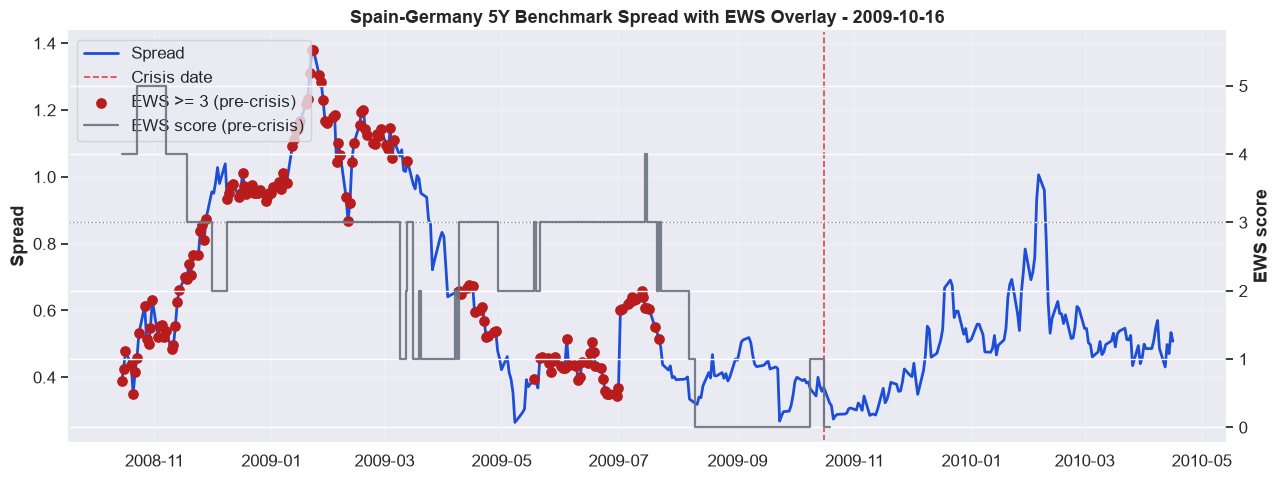

Selected date range for analysis: 1999-12-31 to 2010-05-09


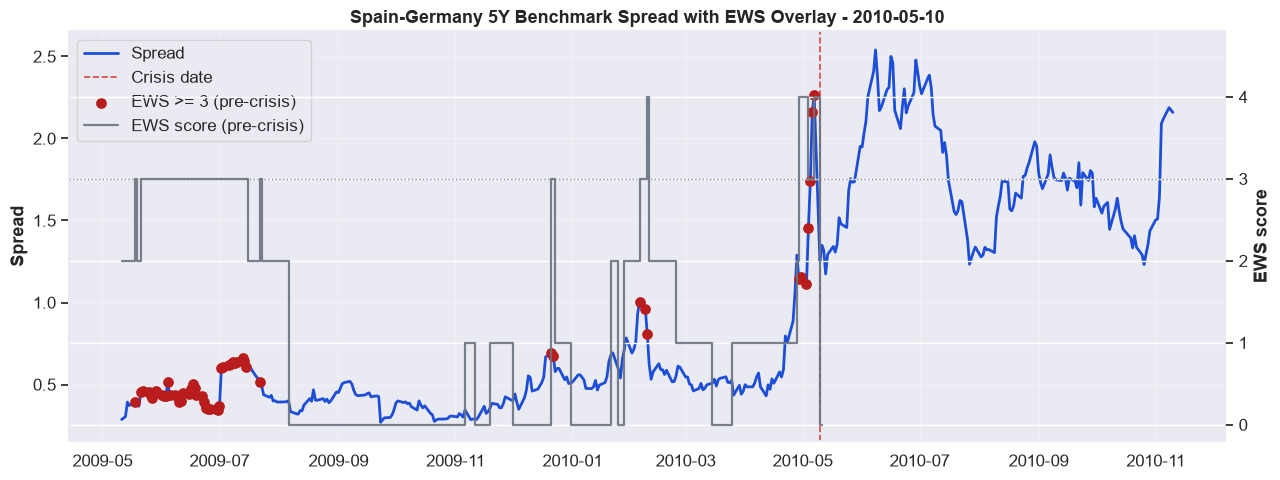

Selected date range for analysis: 1999-12-31 to 2011-08-06


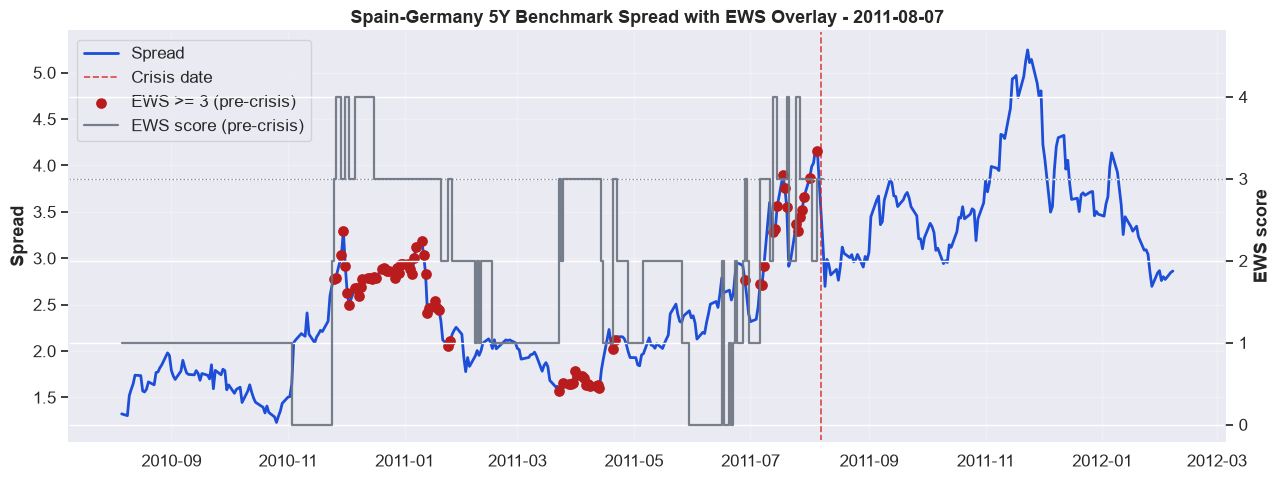

Selected date range for analysis: 1999-12-31 to 2011-12-07


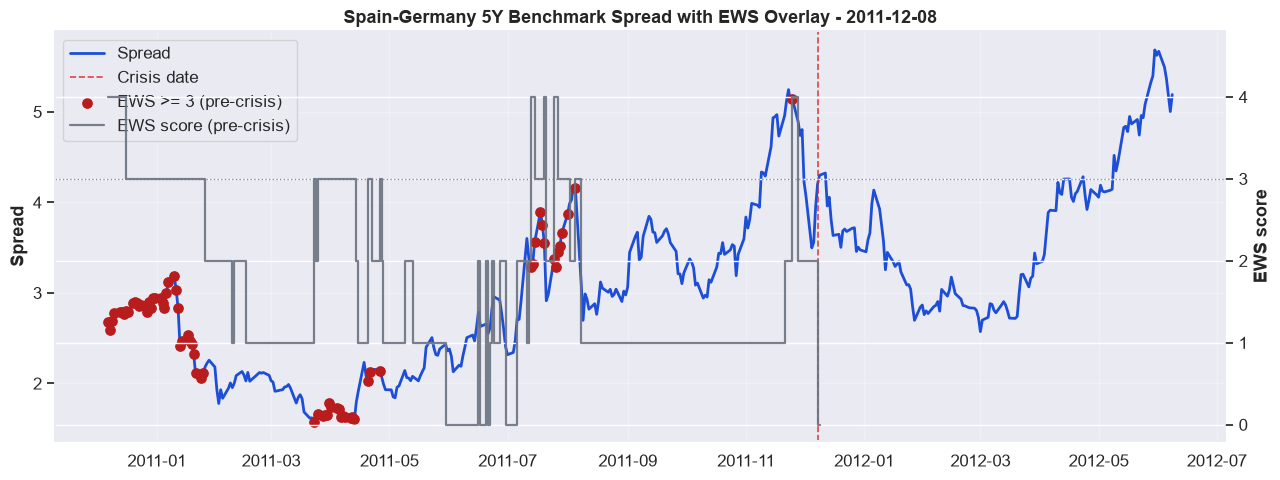

Selected date range for analysis: 1999-12-31 to 2012-06-26


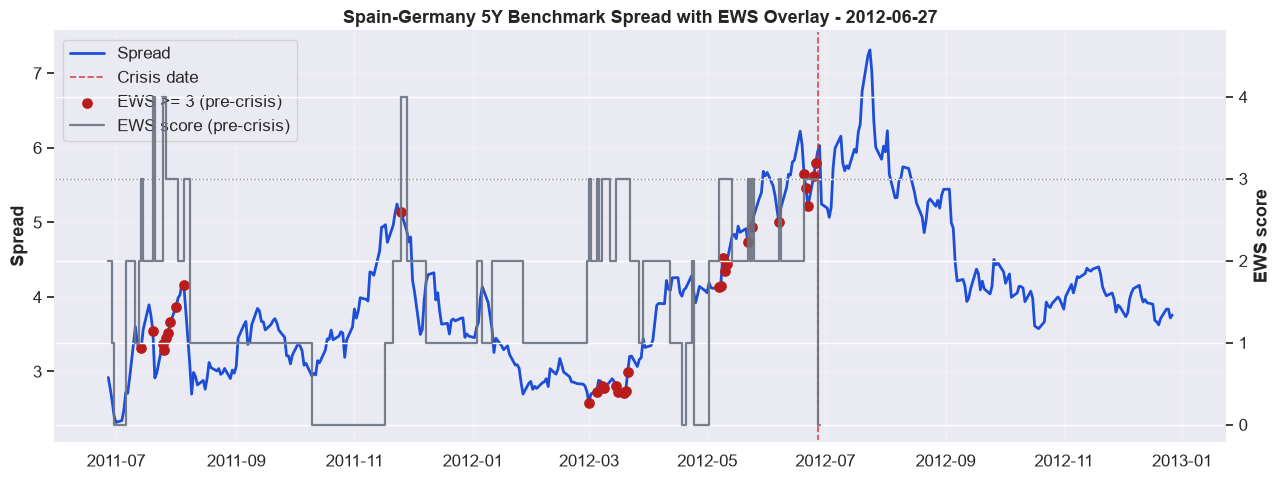

In [45]:
## Now we will plot the behaviour of the EWS leading up to each crisis episode

cutoff_for_extreme_tail = 0.1 # we will look at the lowest/highest 10% of the distribution of each complexity indicator as potential extreme-tail signals
ews_table = pd.DataFrame() # initialize empty table to store results for all events

for j,k in enumerate(event_dates): # spread_widening_date_list
    # Set date range for analysis
    e_date = pd.to_datetime(k) - pd.Timedelta(days=1) # we just set it so that the crisis date is not included
    print(f"Selected date range for analysis: {s_date} to {e_date.strftime('%Y-%m-%d')}")

    # calculating rolling complexity indicators for the selected event date
    df_sov_stress_5y = es_de_spread_5y_df.loc[s_date:e_date.strftime('%Y-%m-%d')].copy()
    rolling_complexity_inds_5y = rolling_complexity_indicators(df=df_sov_stress_5y, value_col="es_de_5y_spread", date_col="observation_date", window=100, min_periods=100, signed_decay=False).copy()

    # calculating complexity indicator signals and ews scores
    crisis_dates = [k]
    thresholds, signals, valid, summary = tail_signals(rolling_complexity_inds_5y, crisis_dates, tail=cutoff_for_extreme_tail, lookback=100, check_all_signals=True)
    ews = ews_score_from_valid(valid) # calculating EWS score based on valid signals

    # Plotting Signals and the Spread
    looking_back_date = (pd.to_datetime(e_date) - pd.Timedelta(days=365))#.strftime('%Y-%m-%d')
    #ending_date = str(e_date.strftime('%Y-%m-%d')) 

    plot_spread_with_ews_overlay(
        spread=es_de_spread_5y_df["es_de_5y_spread"],
        ews_score=ews,
        crisis_date=k,
        start_date=looking_back_date,
        look_after_crisis_date=True,
        look_after_date=None,  # defaults to crisis_date + 6 months
        min_overlay_score=3,
        input_title= f"Spain-Germany 5Y Benchmark Spread with EWS Overlay - {k}" #({s_date}-{e_date.strftime('%Y-%m-%d')})"
    )
    # creating event window table for the selected event date
    ews_event_table = ews_event_window_table(
        df=ews.to_frame(name="EWS"), # ews
        event_dates=[k],
        ews_col="EWS", # matters if ews has multiple columns
        signal_threshold=3,
        pre_window=100,
        horizons=(5, 10, 25, 50, 100)
    )
    
    # optional: tag which loop/event it came from
    ews_event_table["event_idx"] = j
    ews_event_table["event_date_input"] = pd.to_datetime(k)

    ews_table = pd.concat([ews_table, ews_event_table], ignore_index=True)

##### Summary of Episode-Level EWS Results
* **Greek Fiscal Shock:** The Greek fiscal disclosure produced almost no meaningful EWS activity in Spanish spreads, especially in the 50 days before the event. This is interpreted as an informative baseline rather than a failure, since Spain-Germany spreads were not yet in a pre-transitional state.
* **First Eurozone Intervention:** Ahead of the first SMP intervention, EWS activity intensified sharply, with signals concentrated in the final days before the event. This suggests that Spanish spread dynamics had entered a fragile and unstable state shortly before the ECB intervention.
* **Spain Contagion:** The Spain/Italy contagion episode showed the strongest and most sustained EWS activity across longer pre-event windows. This indicates a more gradual build-up of endogenous fragility in Spanish sovereign spreads, making it one of the clearest cases for the methodology.
* **LTRO:** The LTRO episode generated very limited EWS activity, despite spreads remaining elevated. This suggests that the LTRO was primarily a discretionary policy intervention rather than the result of a measurable critical transition in Spanish spread dynamics.
* **Spanish Banking-Sector Assistance:** Before Spain's banking-sector assistance request, EWS signals reappeared and became concentrated in the final days before the anchor date. The indicators did not predict the political decision itself, but they captured the underlying fragility of the spread regime.

### Welch's Two-sided T-test

* In order to check what happens shortly after the Early-Warning Signals, and quantify whether the spread narrowing/widening that follows is significant, we will use a **Welch's two-sided t-test**.
* First, we will calculate the difference in spread levels following the EWS signals for the horizons `5, 10, 15, 20, 25` days and then repeat the same calculation for randomly selected days from the sample.
* So overall, the t-test will compare future spread changes after EWS signal dates against future spread changes after random non-signal dates

In [49]:
## Calculating Future Spread Changes After EWS Signals

def future_spread_changes_after_ews_signals(
    ews_df: pd.Series,
    spread_df: pd.DataFrame,
    spread_date_col: str = "Date",
    spread_col: str = "es_de_5y_spread",
    signal_threshold: int = 3,
    horizons: tuple = (5, 10, 15, 20, 25),
) -> pd.DataFrame:
    """
    For every EWS signal date, return:
    - spread level on the signal date
    - future spread level after h trading days
    - future spread change after h trading days

    Future spread change is calculated using:
        spread.diff(h).shift(-h)

    which equals:
        spread[t+h] - spread[t]
    """

    # --- Prepare EWS series ---
    ews = ews_df.copy()

    if not isinstance(ews.index, pd.DatetimeIndex):
        ews.index = pd.to_datetime(ews.index, errors="coerce")

    ews = ews[~ews.index.isna()]

    # --- Prepare spread series ---
    s = spread_df.copy()

    if spread_date_col in s.columns:
        s[spread_date_col] = pd.to_datetime(s[spread_date_col], errors="coerce")
        s = s.dropna(subset=[spread_date_col]).set_index(spread_date_col)
    else:
        s.index = pd.to_datetime(s.index, errors="coerce")
        s = s[~s.index.isna()]

    s = s.sort_index()

    spread = s[spread_col].astype(float)

    # --- Combine EWS and spread on same date index ---
    out = pd.DataFrame(index=spread.index)
    out["spread_at_signal"] = spread
    out["EWS"] = ews.reindex(out.index)

    # --- Future spread levels and future spread changes ---
    for h in horizons:
        out[f"spread_{h}d_after"] = spread.shift(-h)
        out[f"spread_change_{h}d_after"] = spread.diff(h).shift(-h)

    # --- Keep only EWS signal dates ---
    out = out[out["EWS"] >= signal_threshold].copy()

    # --- Clean output ---
    out = out.reset_index().rename(columns={out.index.name or "index": "date"})

    return out

In [51]:
## Calculating Future Spread Changes After EWS Signals for the Spain-Germany 5Y Spread
signal_change_table = future_spread_changes_after_ews_signals(
    ews_df=ews,
    spread_df=es_de_spread_5y_df,
    spread_date_col="Date",
    spread_col="es_de_5y_spread",
    signal_threshold=3,
    horizons=(5, 10, 15, 20, 25),
)

signal_change_table.head()

,date,spread_at_signal,EWS,spread_5d_after,spread_change_5d_after,spread_10d_after,spread_change_10d_after,spread_15d_after,spread_change_15d_after,spread_20d_after,spread_change_20d_after,spread_25d_after,spread_change_25d_after
0,2005-07-07,0.098,4.0,0.076,-0.022,0.066,-0.032,0.054,-0.044,0.059,-0.039,0.030,-0.068
1,2005-07-11,0.077,3.0,0.066,-0.011,0.060,-0.017,0.051,-0.026,0.056,-0.021,0.047,-0.030
2,2005-07-12,0.070,3.0,0.050,-0.020,0.054,-0.016,0.065,-0.005,0.059,-0.011,0.035,-0.035
3,2005-07-14,0.076,3.0,0.066,-0.010,0.054,-0.022,0.059,-0.017,0.030,-0.046,0.046,-0.030
4,2005-07-15,0.063,3.0,0.050,-0.013,0.062,-0.001,0.070,0.007,0.038,-0.025,0.057,-0.006


In [61]:
## Calculating Future Spread Changes After random non-signal dates

def random_future_spread_table(
    forecast_table: pd.DataFrame,
    ews_df: pd.Series,
    spread_df: pd.DataFrame,
    ews_date_col: str = "observation_date",  # kept for compatibility
    spread_date_col: str = "Date",
    spread_col: str = "es_de_5y_spread",
    horizons: tuple = (5, 10, 15, 20, 25),
    seed: int = 42,
    exclude_signal_dates: bool = True,
) -> pd.DataFrame:
    """
    Randomly select the same number of dates as forecast_table and return:
    - spread level on the random date
    - future spread level after h trading days
    - future spread change after h trading days

    Future spread change is calculated as:
        spread.diff(h).shift(-h)

    which equals:
        spread[t+h] - spread[t]
    """

    rng = np.random.default_rng(seed)
    n_random_dates = len(forecast_table)

    # --- EWS date range from Series index ---
    ews = ews_df.copy()

    if not isinstance(ews.index, pd.DatetimeIndex):
        ews.index = pd.to_datetime(ews.index, errors="coerce")

    ews = ews[~ews.index.isna()]
    ews_dates = pd.DatetimeIndex(ews.index.unique()).sort_values()

    if len(ews_dates) == 0:
        raise ValueError("ews_df has no valid datetime index values.")

    ews_start, ews_end = ews_dates.min(), ews_dates.max()

    # --- Prepare spread dataframe ---
    s = spread_df.copy()

    if spread_date_col in s.columns:
        s[spread_date_col] = pd.to_datetime(s[spread_date_col], errors="coerce")
        s = s.dropna(subset=[spread_date_col]).set_index(spread_date_col)
    else:
        s.index = pd.to_datetime(s.index, errors="coerce")
        s = s[~s.index.isna()]

    s = s.sort_index()

    if spread_col not in s.columns:
        raise KeyError(f"`{spread_col}` not found. Available columns: {list(s.columns)}")

    # Restrict spread to same date range as EWS
    spread = s.loc[ews_start:ews_end, spread_col].dropna().astype(float)

    if spread.empty:
        raise ValueError(
            f"No spread data found in EWS window [{ews_start.date()} .. {ews_end.date()}]."
        )

    # --- Build full table with future levels and future changes ---
    data = pd.DataFrame(index=spread.index)
    data["spread_at_signal"] = spread

    for h in horizons:
        data[f"spread_{h}d_after"] = spread.shift(-h)
        data[f"spread_change_{h}d_after"] = spread.diff(h).shift(-h)

    # Drop dates where future horizons are not available
    future_cols = []
    for h in horizons:
        future_cols += [f"spread_{h}d_after", f"spread_change_{h}d_after"]

    data = data.dropna(subset=future_cols).copy()

    candidate_dates = pd.DatetimeIndex(data.index)

    # Optionally remove original EWS signal dates
    if exclude_signal_dates:
        signal_dates = pd.to_datetime(forecast_table["date"], errors="coerce")
        signal_dates = pd.DatetimeIndex(signal_dates.dropna().unique())
        candidate_dates = candidate_dates.difference(signal_dates)

    if len(candidate_dates) < n_random_dates:
        raise ValueError(
            f"Not enough candidate dates ({len(candidate_dates)}) for {n_random_dates} rows. "
            f"Try fewer rows, smaller horizons, or exclude_signal_dates=False."
        )

    # --- Random selection happens here ---
    random_dates = pd.DatetimeIndex(
        rng.choice(candidate_dates.to_numpy(), size=n_random_dates, replace=False)
    ).sort_values()

    random_table = data.loc[random_dates].copy()

    random_table = (
        random_table
        .reset_index()
        .rename(columns={random_table.index.name or "index": "date"})
    )

    return random_table

In [69]:
## Calculating Future Spread Changes After randomly selected days from the sample

random_change_table = random_future_spread_table(
    forecast_table=signal_change_table,
    ews_df=ews,
    spread_df=es_de_spread_5y_df,
    spread_date_col="Date",
    spread_col="es_de_5y_spread",
    horizons=(5, 10, 15, 20, 25),
    seed=42,
    exclude_signal_dates=True,
)

random_change_table.head()

,date,spread_at_signal,spread_5d_after,spread_change_5d_after,spread_10d_after,spread_change_10d_after,spread_15d_after,spread_change_15d_after,spread_20d_after,spread_change_20d_after,spread_25d_after,spread_change_25d_after
0,2000-02-01,0.257,0.247,-0.010,0.240,-0.017,0.201,-0.056,0.186,-0.071,0.212,-0.045
1,2000-06-09,0.277,0.261,-0.016,0.260,-0.017,0.297,0.020,0.289,0.012,0.313,0.036
2,2000-07-04,0.277,0.292,0.015,0.254,-0.023,0.267,-0.010,0.258,-0.019,0.263,-0.014
3,2000-09-26,0.300,0.288,-0.012,0.243,-0.057,0.269,-0.031,0.271,-0.029,0.280,-0.020
4,2000-10-13,0.297,0.244,-0.053,0.276,-0.021,0.256,-0.041,0.254,-0.043,0.251,-0.046


In [59]:
## Performing the t-test for each each horzion for the two groups

def compare_future_spread_changes(
    signal_table: pd.DataFrame,
    random_table: pd.DataFrame,
    change_prefix: str = "spread_change_",
    alternative: str = "greater"
) -> pd.DataFrame:
    """
    Compare future spread changes after EWS signal dates versus random dates.

    alternative='greater' tests:
        mean(signal future spread change) > mean(random future spread change)

    In other words:
        Are spreads widening more after EWS signal dates than after random dates?
    """

    horizon_cols = [
        col for col in signal_table.columns
        if col.startswith(change_prefix) and col.endswith("d_after")
    ]

    rows = []

    for col in horizon_cols:
        signal_values = signal_table[col].dropna()
        random_values = random_table[col].dropna()

        t_stat, p_value = ttest_ind(
            signal_values,
            random_values,
            equal_var=False, # Welch t-test -> the two groups can have different variances (Student's_date t-test assumes equal variances)
            alternative=alternative
        )

        rows.append({
            "horizon": col,
            "n_signal": len(signal_values),
            "n_random": len(random_values),
            "signal_mean_change": signal_values.mean(),
            "random_mean_change": random_values.mean(),
            "signal_median_change": signal_values.median(),
            "random_median_change": random_values.median(),
            "signal_std_change": signal_values.std(),
            "random_std_change": random_values.std(),
            "mean_difference": signal_values.mean() - random_values.mean(),
            "t_stat": t_stat,
            "p_value": p_value
        })

    return pd.DataFrame(rows)

In [66]:
## Looking at the t-test results
spread_change_ttest_results = compare_future_spread_changes(
    signal_table=signal_change_table,
    random_table=random_change_table,
    alternative="two-sided"
)

spread_change_ttest_results

,horizon,n_signal,n_random,signal_mean_change,random_mean_change,signal_median_change,random_median_change,signal_std_change,random_std_change,mean_difference,t_stat,p_value
0,spread_change_5d_after,130,130,-0.006415,0.019254,-0.0060,0.0015,0.361989,0.105548,-0.025669,-0.776195,0.438850
1,spread_change_10d_after,130,130,-0.075215,0.032469,-0.0165,0.0025,0.429104,0.158554,-0.107685,-2.683935,0.008025
2,spread_change_15d_after,130,130,-0.081738,0.039185,-0.0185,-0.0050,0.597431,0.189229,-0.120923,-2.200052,0.029287
3,spread_change_20d_after,130,130,-0.073169,0.041523,-0.0400,-0.0010,0.690369,0.243684,-0.114692,-1.786188,0.075955
4,spread_change_25d_after,130,130,-0.096392,0.032492,-0.0815,-0.0005,0.719055,0.238650,-0.128885,-1.939632,0.054216


**Results of the Two-sided Welch's T-test:**
- The test compares **130 EWS signal dates** with **130 randomly selected non-signal dates** at each horizon.

- Across all horizons, the average spread change after EWS signals is **negative**, while the random-date average is slightly **positive**. So, in this sample, EWS signals are followed more by **spread narrowing** than widening.

- The difference is statistically significant at the 5% level for the **10-day horizon** and **15-day horizon**:
  - 10 days: mean difference ≈ `-0.108`, p-value ≈ `0.008`
  - 15 days: mean difference ≈ `-0.121`, p-value ≈ `0.029`

- The **5-day horizon** is not significant, with p-value ≈ `0.439`, suggesting little evidence of an immediate difference after signals.

- The **20-day** and **25-day** horizons are close to significance but do not pass the 5% threshold:
  - 20 days: p-value ≈ `0.076`
  - 25 days: p-value ≈ `0.054`

- Overall, the results suggest that EWS signal dates are followed by **more negative spread changes than random dates**, especially over the 10-15 day window. This points toward post-signal spread narrowing rather than widening in the tested sample, but this actually aligns with the ideas of complexity theory, since complexity indicators aim to detect the built-up fragility in the state variable and not necessarily predict spread widening/narrowing.

### Analysing Pre-episode Signal Behaviour

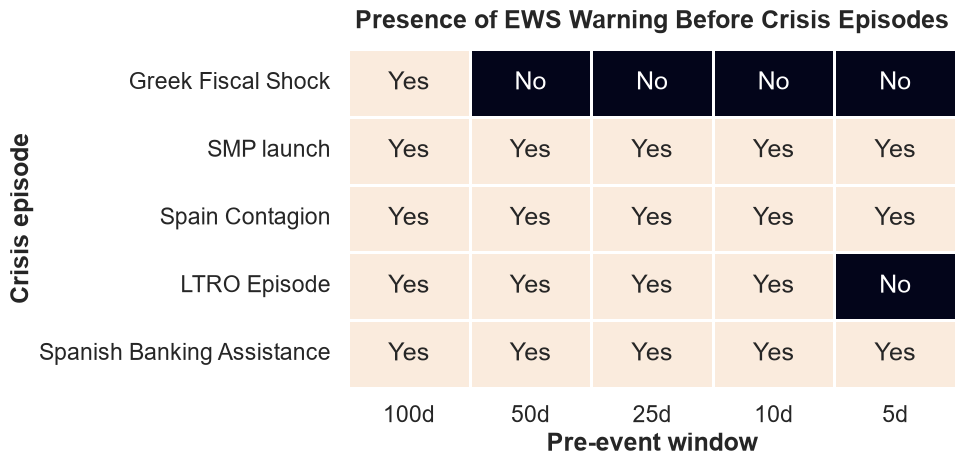

In [72]:
## Binary event-window heatmap for analysing the presence of pre-episode EWS signals
# A cell marked Yes means: At least one day in that window had EWS≥3.
# So if Greek fiscal shock has: 100d = Yes, 50d = No, 25d = No, 10d = No, 5d = No -> then the EWS gave an early vulnerability signal, but not an immediate warning close to the event.

df = ews_table.copy()
df["event_date"] = pd.to_datetime(df["event_date"])

# Add readable event labels
episode_names = {
    #"2009-10-16": "Greek fiscal disclosure",
    "2009-10-16": "Greek Fiscal Shock",
    #"2010-05-10": "First ECB sovereign-market intervention - SMP launch",
    "2010-05-10": "SMP launch",
    #"2011-08-07": "Spain/Italy contagion and SMP expansion",
    "2011-08-07": "Spain Contagion",
    #"2011-12-08": "3Y LTRO liquidity episode",
    "2011-12-08": "LTRO Episode",
    #"2012-06-27": "Spanish banking-sector assistance",
    "2012-06-27": "Spanish Banking Assistance",
}

df["episode"] = df["event_date"].dt.strftime("%Y-%m-%d").map(episode_names)

# Fallback if any label is missing
df["episode"] = df["episode"].fillna(df["event_date"].dt.strftime("%Y-%m-%d"))

heatmap_cols = [
    "any_signal_pre_100d",
    "any_signal_pre_50d",
    "any_signal_pre_25d",
    "any_signal_pre_10d",
    "any_signal_pre_5d",
]

heatmap_labels = ["100d", "50d", "25d", "10d", "5d"]

heatmap_data = df.set_index("episode")[heatmap_cols]
heatmap_data.columns = heatmap_labels

# Replace 1/0 annotations with Yes/No or symbols
annot = heatmap_data.replace({1: "Yes", 0: "No"})

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10, 5))
ax = sns.heatmap(
    heatmap_data,
    annot=annot,
    fmt="",
    linewidths=0.8,
    linecolor="white",
    cbar=False
)

ax.set_title("Presence of EWS Warning Before Crisis Episodes", pad=15)
ax.set_xlabel("Pre-event window")
ax.set_ylabel("Crisis episode")

plt.tight_layout()
plt.show()

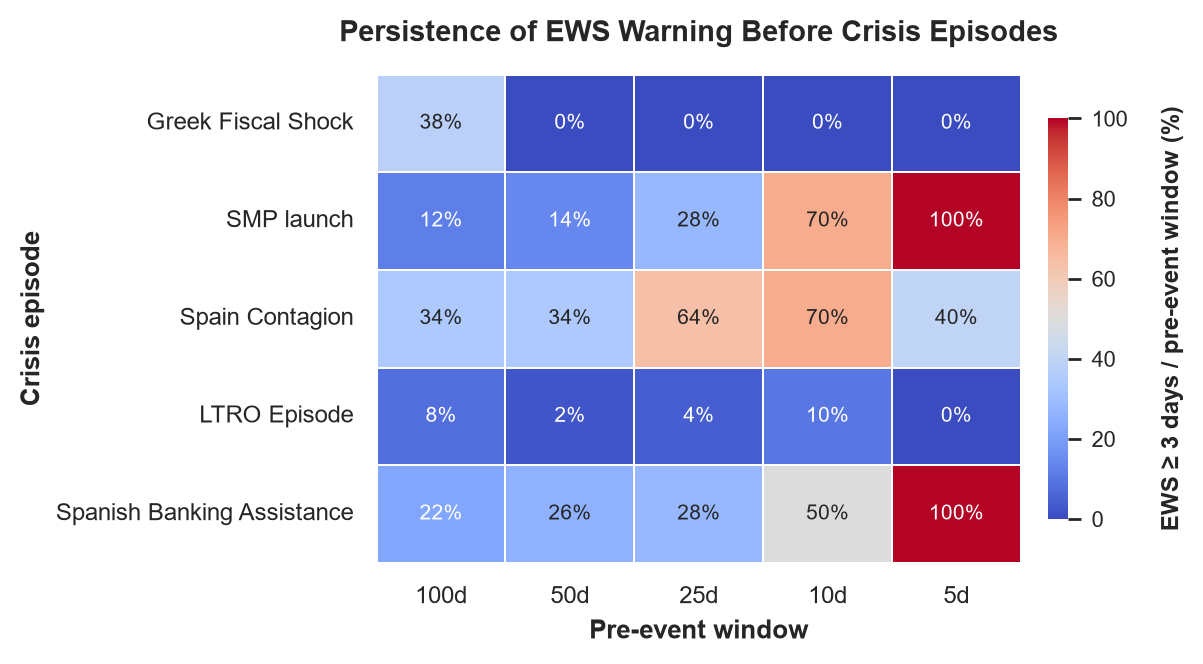

In [78]:
## Now we will create a heatmap showing the percentage of days in each pre-event window that had EWS≥3, for each crisis episode
# Recreate persistence_data from ews_table

df = ews_table.copy()
df["event_date"] = pd.to_datetime(df["event_date"])

episode_names = {
    "2009-10-16": "Greek Fiscal Shock",
    "2010-05-10": "SMP launch",
    "2011-08-07": "Spain Contagion",
    "2011-12-08": "LTRO Episode",
    "2012-06-27": "Spanish Banking Assistance",
}

df["episode"] = df["event_date"].dt.strftime("%Y-%m-%d").map(episode_names)
df["episode"] = df["episode"].fillna(df["event_date"].dt.strftime("%Y-%m-%d"))

persistence_data = (
    df
    .set_index("episode")
    [[
        "signal_days_pre_100d",
        "signal_days_pre_50d",
        "signal_days_pre_25d",
        "signal_days_pre_10d",
        "signal_days_pre_5d",
    ]]
    .rename(columns={
        "signal_days_pre_100d": "100d",
        "signal_days_pre_50d": "50d",
        "signal_days_pre_25d": "25d",
        "signal_days_pre_10d": "10d",
        "signal_days_pre_5d": "5d",
    })
    .astype(int)
)


window_cols = ["100d", "50d", "25d", "10d", "5d"]

window_lengths = pd.Series({
    "100d": 100,
    "50d": 50,
    "25d": 25,
    "10d": 10,
    "5d": 5
})

# Since episode is already the index
pers = persistence_data.copy()
heatmap_data = pers[window_cols]

# Convert raw counts to percentages
heatmap_pct = heatmap_data.divide(window_lengths, axis=1) * 100

# Percentage annotations
annot = heatmap_pct.round(0).astype(int).astype(str) + "%"

# Wrap long labels
wrapped_index = [
    "\n".join(textwrap.wrap(str(label), width=48))
    for label in heatmap_pct.index
]

heatmap_pct.index = wrapped_index
annot.index = wrapped_index

sns.set_theme(style="whitegrid", context="paper")

fig, ax = plt.subplots(figsize=(7.6, 3.7), dpi=200)

hm = sns.heatmap(
    heatmap_pct,
    annot=annot,
    fmt="",
    cmap="coolwarm",          # same blue-white-red style
    vmin=0,
    vmax=100,
    linewidths=0.7,
    linecolor="white",
    cbar=True,
    cbar_kws={
        "label": "EWS ≥ 3 days / pre-event window (%)",
        "shrink": 0.82,
        "pad": 0.035
    },
    annot_kws={
        "fontsize": 7.5
    },
    ax=ax
)

ax.set_title(
    "Persistence of EWS Warning Before Crisis Episodes",
    fontsize=10.5,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Pre-event window", fontsize=9.5, fontweight="bold")
ax.set_ylabel("Crisis episode", fontsize=9.5, fontweight="bold")

ax.tick_params(axis="x", rotation=0, labelsize=8.5)
ax.tick_params(axis="y", rotation=0, labelsize=8.5)

# Colorbar formatting
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
cbar.ax.yaxis.label.set_size(8.5)
cbar.ax.yaxis.labelpad = 12

# Layout control to avoid overlap
fig.subplots_adjust(
    left=0.36,
    right=0.88,
    top=0.84,
    bottom=0.18
)
plt.show()

##### Merged Plotting of Crisis Events

In [86]:
## Additionally, we can visualise chronologically the EWS signals leading up to each crisis episode, overlaid on the Spain-Germany 5Y spread.

def plot_event_episode_spread_ews(
    spread_df,
    spread_col="es_de_5y_spread",
    selected_events=None,
    s_date="1999-12-31",
    plot_start="2008-01-01",
    plot_end="2013-01-01",
    cutoff_for_extreme_tail=0.1,
    min_overlay_score=3,
    pre_signal_window=365,
    show_only_high_ews=True,
    title="Spain-Germany 5Y Spread with Event-Specific EWS Signals",
    spread_label="Spain-Germany 5Y spread",
    save_path=None,
    dpi=300
):
    fig, ax = plt.subplots(figsize=(15, 6))

    spread = spread_df[spread_col].copy()
    if not isinstance(spread.index, pd.DatetimeIndex):
        spread.index = pd.to_datetime(spread_df["observation_date"])

    plot_data = spread.loc[pd.to_datetime(plot_start):pd.to_datetime(plot_end)]

    ax.plot(
        plot_data.index,
        plot_data,
        color="#1D4ED8",
        lw=2.2,
        label="_nolegend_",
        zorder=2,
    )

    for event_date, event_label, event_color in selected_events:
        event_dt = pd.to_datetime(event_date)
        e_date = event_dt - pd.Timedelta(days=1)

        df_event = spread_df.loc[s_date:e_date.strftime("%Y-%m-%d")].copy()

        rolling_inds = rolling_complexity_indicators(
            df=df_event,
            value_col=spread_col,
            date_col="observation_date",
            window=100,
            min_periods=100,
            signed_decay=False,
        ).copy()

        thresholds, signals, valid, summary = tail_signals(
            rolling_inds,
            [event_dt],
            tail=cutoff_for_extreme_tail,
            lookback=100,
            check_all_signals=True,
        )

        ews = ews_score_from_valid(valid)

        signal_start = event_dt - pd.Timedelta(days=pre_signal_window)
        ews_window = ews.loc[signal_start:e_date]

        if show_only_high_ews:
            signal_mask = ews_window >= min_overlay_score
        else:
            signal_mask = ews_window > 0

        dot_dates = ews_window.index[signal_mask]
        dot_values = spread.reindex(dot_dates)

        ax.scatter(
            dot_dates,
            dot_values,
            s=48,
            color=event_color,
            edgecolor="white",
            linewidth=0.6,
            zorder=5,
            label="_nolegend_",
        )

        ax.axvline(
            event_dt,
            color=event_color,
            lw=2.3,
            ls="--",
            alpha=0.9,
            zorder=1,
            label="_nolegend_",
        )

        ax.text(
            event_dt,
            ax.get_ylim()[1],
            event_label,
            rotation=90,
            va="top",
            ha="right",
            fontsize=12,
            color=event_color,
            fontweight="bold",
        )

    signal_label = f"EWS Signals" if show_only_high_ews else "EWS > 0"

    legend_handles = [
        Line2D(
            [0], [0],
            color="#1D4ED8",
            lw=2.2,
            label=spread_label,
        )
    ]

    for _, event_label, event_color in selected_events:
        legend_handles.append(
            Line2D(
                [0], [0],
                marker="o",
                linestyle="None",
                markerfacecolor=event_color,
                markeredgecolor="white",
                markersize=8,
                label=f"{signal_label} before {event_label}",
            )
        )

    ax.set_title(title)
    ax.set_ylabel("Spread")
    ax.set_xlabel("")

    ax.grid(True, color="white", linewidth=1.2, alpha=0.9)
    ax.set_axisbelow(True)

    ax.set_xlim(pd.to_datetime(plot_start), pd.to_datetime(plot_end))

    ax.legend(
        handles=legend_handles,
        loc="upper left",
        frameon=True,
        fontsize=10,
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

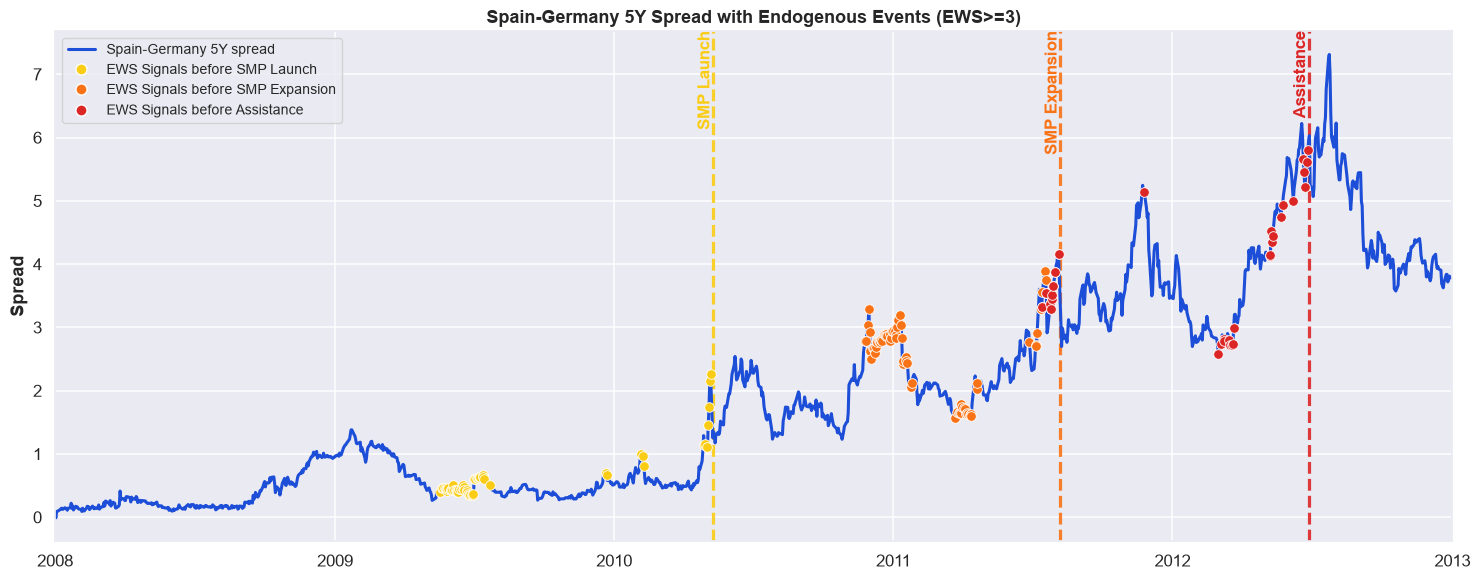

In [87]:
selected_sov_events = [
    ("2010-05-10", "SMP Launch", "#FACC15"),  # yellow
    ("2011-08-07", "SMP Expansion", "#F97316"),  # orange
    ("2012-06-27", "Assistance", "#DC2626"),  # red
]

plot_event_episode_spread_ews(
    spread_df=es_de_spread_5y_df,
    selected_events=selected_sov_events,
    plot_start="2008-01-01",
    plot_end="2013-01-01",
    title="Spain-Germany 5Y Spread with Endogenous Events (EWS>=3)",
    save_path="spain_germany_end_events_ews300.png",
    dpi=350,
)

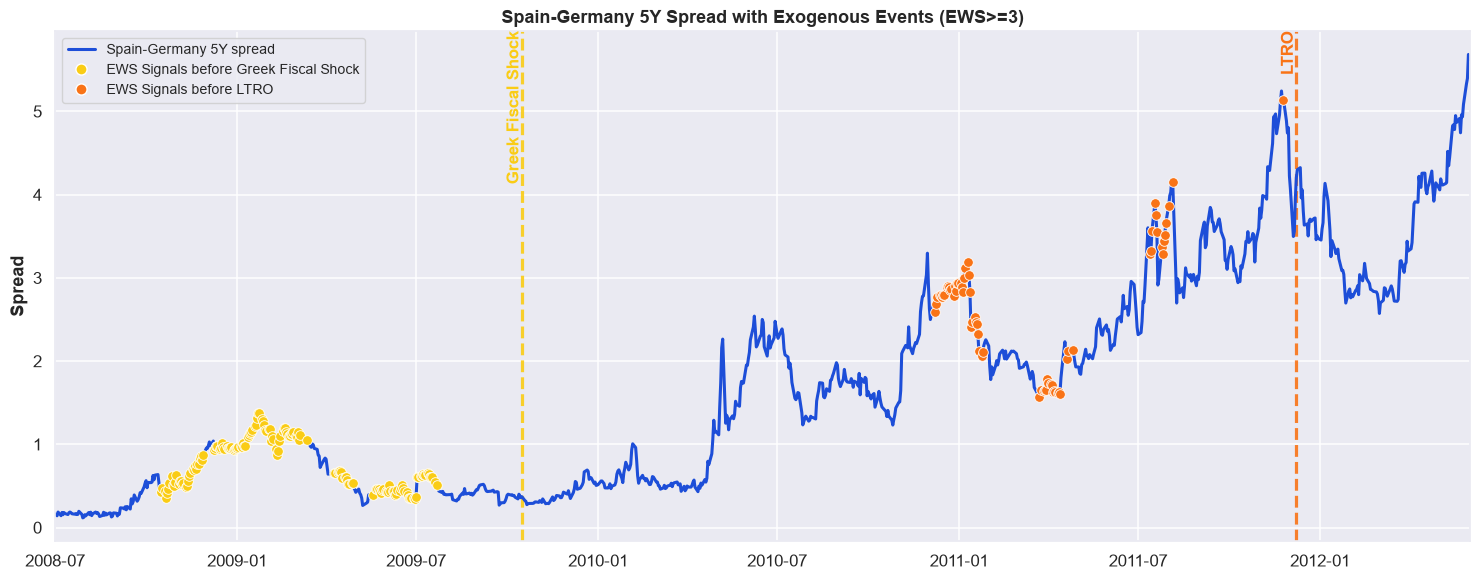

In [88]:
selected_exogenous_events = [
    ("2009-10-16", "Greek Fiscal Shock", "#FACC15"),
    ("2011-12-08", "LTRO", "#F97316"),
]

plot_event_episode_spread_ews(
    spread_df=es_de_spread_5y_df,
    selected_events=selected_exogenous_events,
    plot_start="2008-07-01",
    plot_end="2012-06-01",
    title="Spain-Germany 5Y Spread with Exogenous Events (EWS>=3)",
    save_path="spain_germany_ex_events.png",
    dpi=350,
)

### Conclusion

* **Overall finding:** The results are cautiously supportive of the early-warning-signal framework. The indicators were most useful before episodes driven by endogenous fragility in Spanish sovereign spreads, while they were less active before events driven mainly by external shocks or discretionary policy decisions.

* **Interpretation of EWS signals:** The EWS score should be interpreted as a marker of elevated systemic fragility rather than as a directional predictor of further spread widening. Signal dates identify periods in which the spread regime is unstable and vulnerable to transition, and we can consistently observe that policy intervention tends to follow in these situations.

* **Future research:** The framework could be extended to other sovereign spread pairs, such as Italy-Germany or Portugal-Germany, as well as to emerging market spreads or currency pairs with regime-shift dynamics. Further work could also examine which individual indicators drive the composite score and whether policymakers respond to similar market signals.
